In [10]:
from diagnostics import * 

import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [37]:
# Default parameters
J = 7
Q = 3
M = 128
sigma = 1
nt = 6000
n1 = 2000

# data preparation 
W = DefineWavelet('Db', m=4, device=device)

Data = load_turbulence_1d()
n_initial = 1024
Data = split_periodize_reshape(Data, n_initial)

if M == 128: 
    scales = 3
if M == 256: 
    scales = 3
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1]).to(device)

print('x1 shape:', x1.shape)

x1 shape: torch.Size([2000, 1, 128])


In [39]:
# ------------------------------------------------------------------
# Experiment definitions
# ------------------------------------------------------------------
experiments = {
    # '2GG+PowerLaw': {
    #     'label': '2GG+PowerLaw ψ',
    #     'suffix': '_nt3000_n1_2000_windows_lam_5e-08',
    #     'terms': [
    #         'L_2_lowpass',
    #         'Scattering_Fourth_Order_Real_Q1',
    #         'Scalar_psi_coshgt',
    #         'Scalar_morlet_coshgt',
    #     ],
    # },
    # 'GG+GGamma': {
    #     'label': 'GG+GGamma ψ',
    #     'suffix': '_nt3000_n1_5000_windows_lam_5e-08',
    #     'terms': [
    #         'L_2_lowpass',
    #         'Scattering_Fourth_Order_Real_Q1',
    #         'Scalar_psi_coshgt',
    #         'Scalar_morlet_coshgt',
    #     ],
    # },
    '2GG+PL': {
        'label': '2GG+PL ψ',
        'suffix': f'_nt{nt}_n1_{n1}_windows_lam_5e-08',
        'terms': [
            'L_2_lowpass',
            'Scattering_Fourth_Order_Mod2_Real_Q1',
            'Scalar_psi_windows',
            'Scalar_morlet_windows',
        ],
    },
}

for key, exp in experiments.items():
    # Check if it's the last experiment and adjust parameters
    #if key == 'GGG':
    #    current_M, current_J = 256, 7
    #else:
    current_M, current_J = M, J
    print(current_M, current_J)
        
    base_config = f'turbulence_synthesis_{current_M}_J_{current_J}_Q_{Q}_sigma_{sigma}'
    
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])

128 7
2GG+PL -> turbulence_synthesis_128_J_7_Q_3_sigma_1_nt6000_n1_2000_windows_lam_5e-08


## Optionally coarse grain and compute diagnostics 

Loading 2GG+PL ψ ...
All experiments loaded.
torch.Size([2000, 1, 128])
Marginal histograms


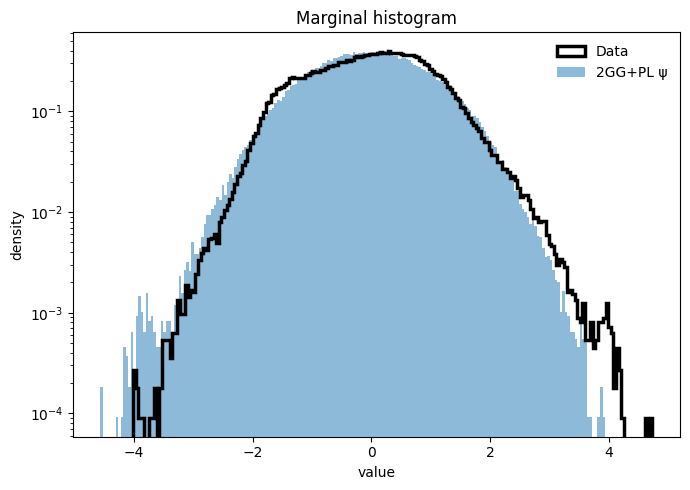

Per-band wavelet histograms  (one model at a time)


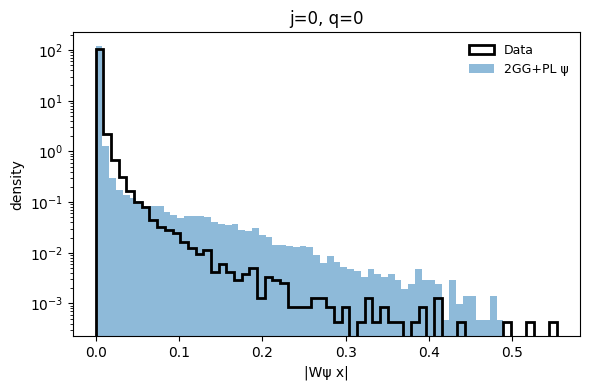

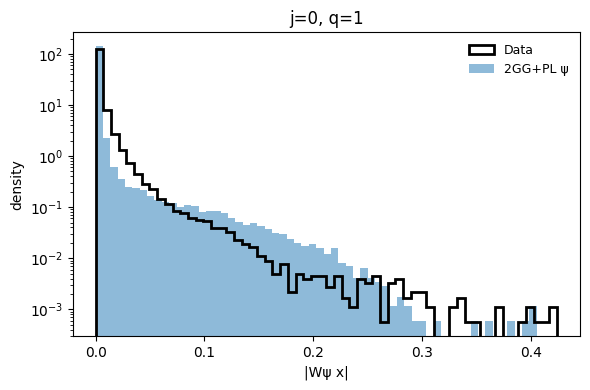

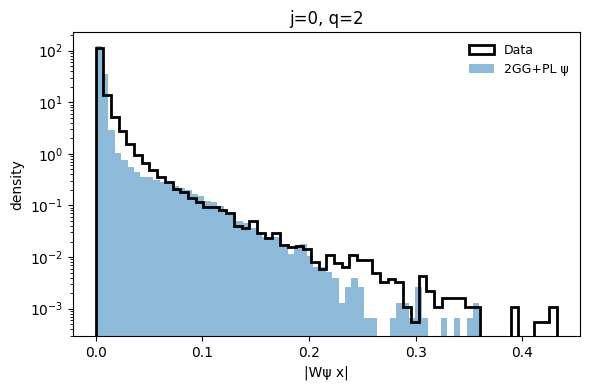

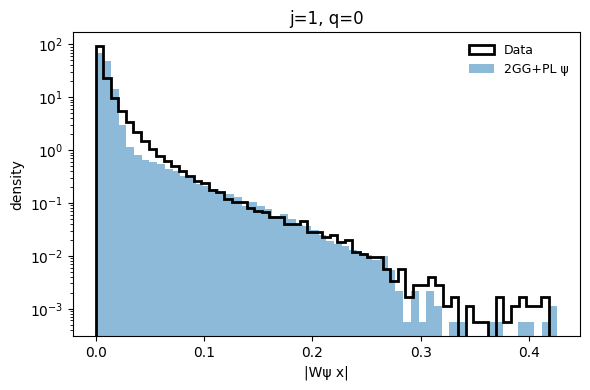

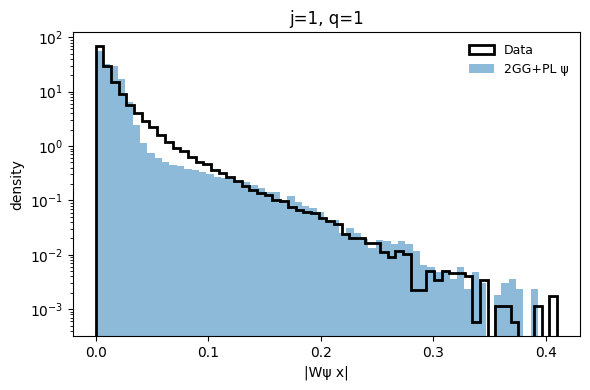

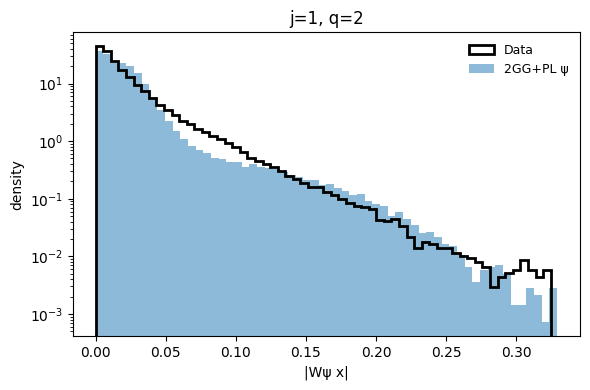

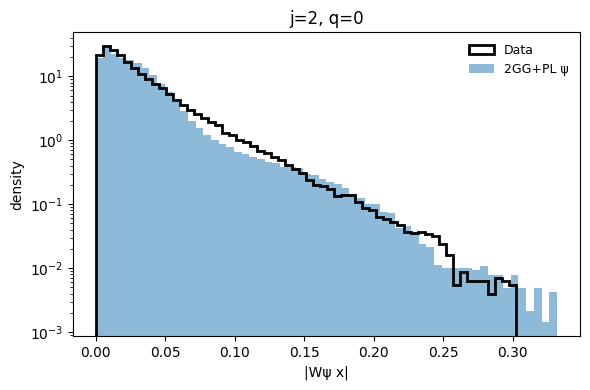

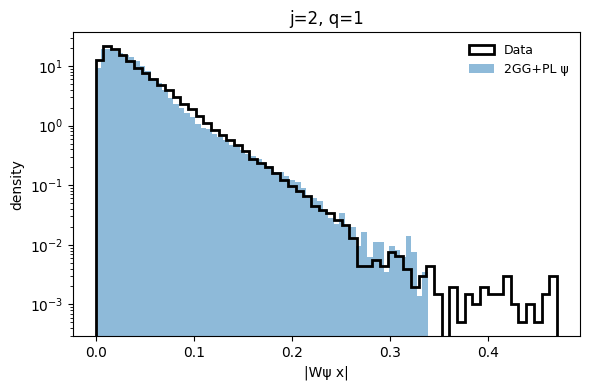

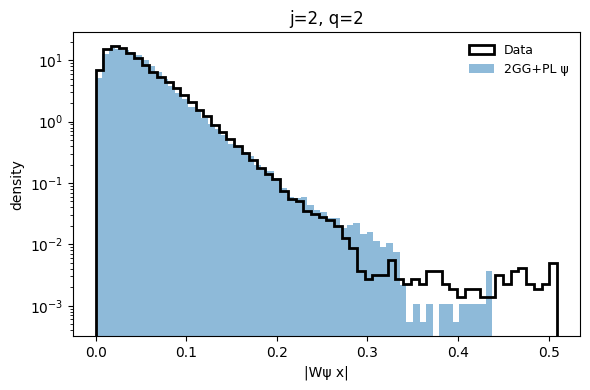

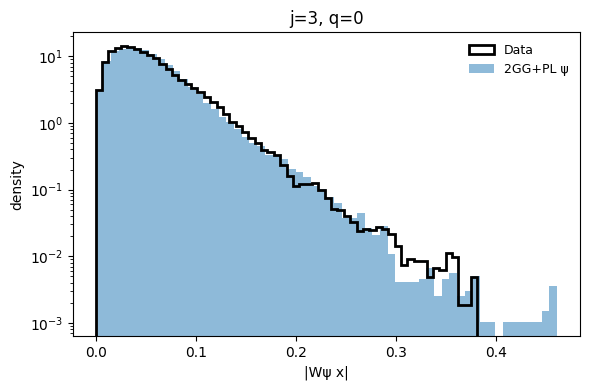

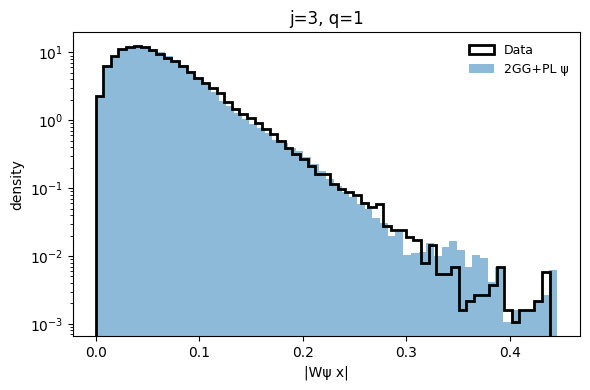

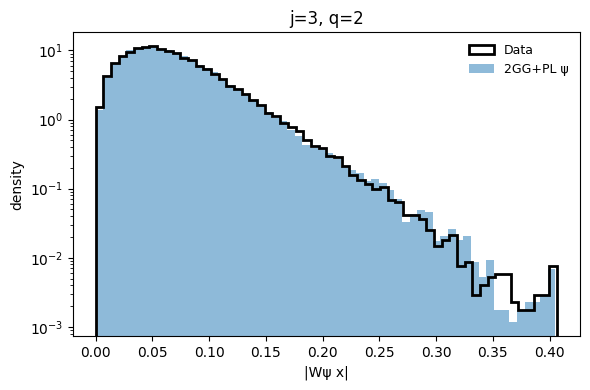

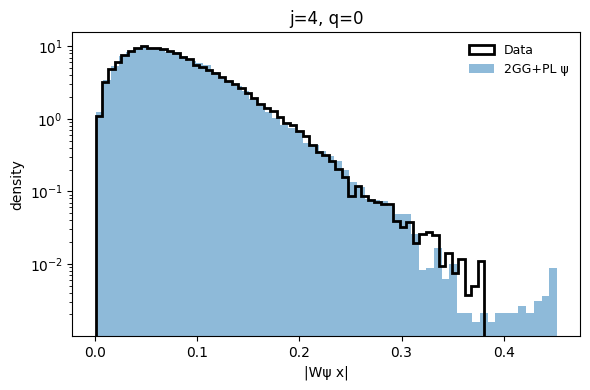

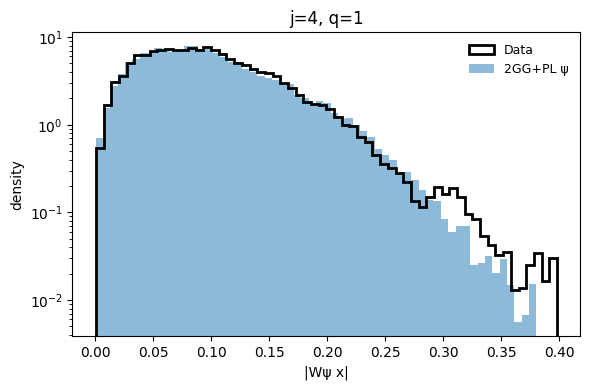

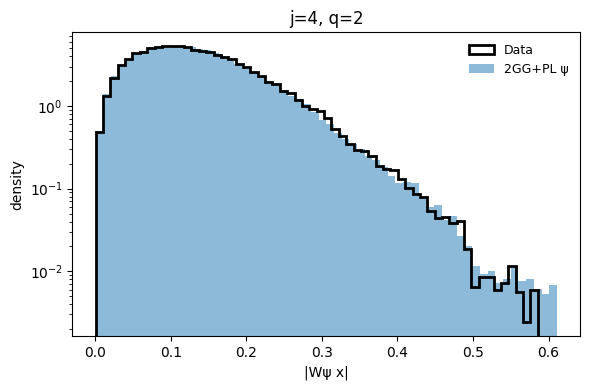

Visual comparison panels


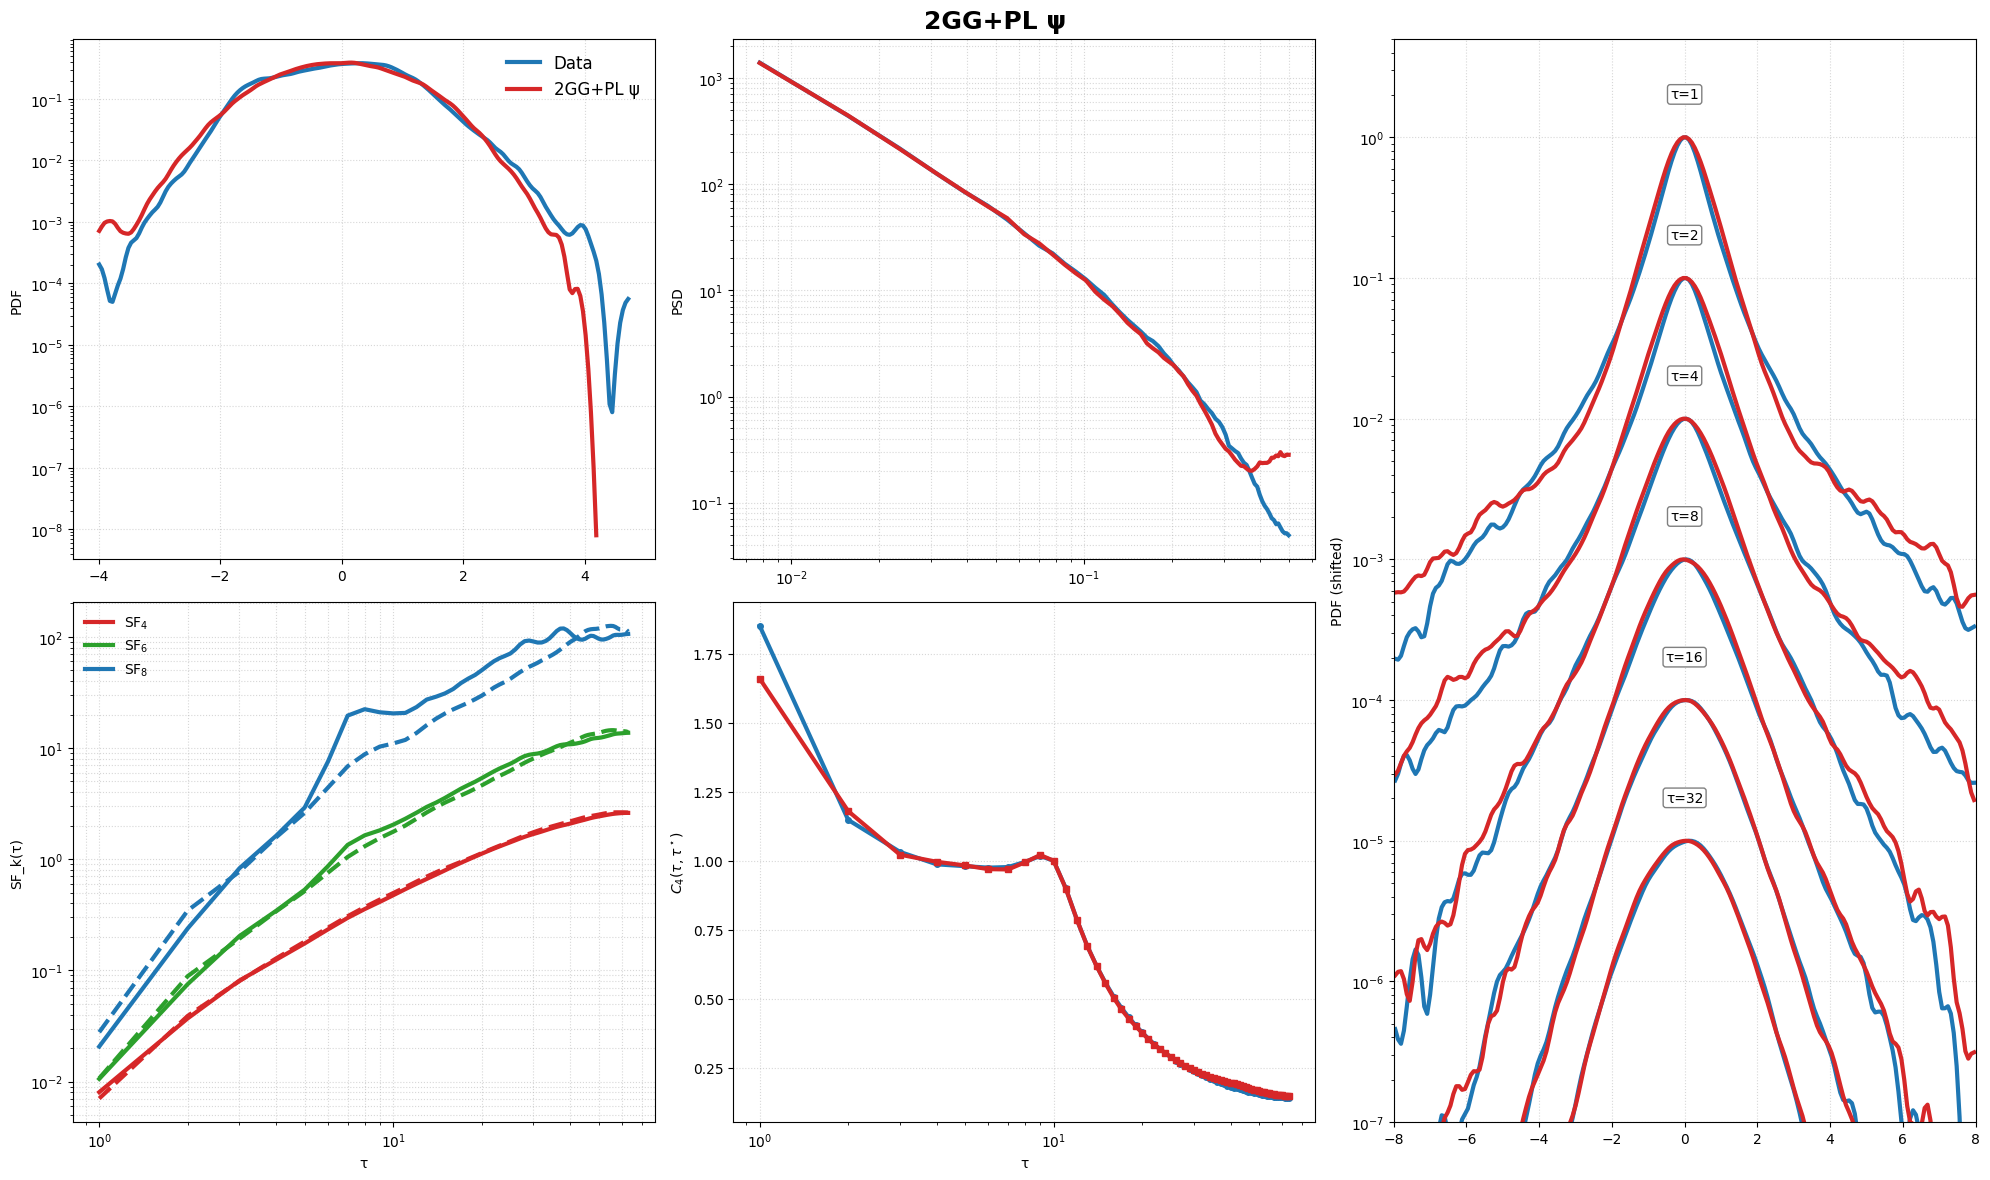

Scalar metrics
          mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
2GG+PL ψ        924927.0       0.001065          0.000001          0.046592           0.000936


,mean_rel_error,std_rel_error,spectrum_rel_mse,wasserstein_mean,structure_rel_mse
2GG+PL ψ,924927.0,0.001065,0.000001,0.046592,0.000936


In [40]:
# 1. Load your experiments as you normally do
results = load_all_experiments(experiments, root, device)

# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, exp in experiments.items():
    xt = results[key]['xt']
    print(xt.shape) 
    
    # Check if the signal length matches your 256 experiment
    # Assuming the dimension to change is the last axis (e.g., shape [-1])
    # if xt.shape[-1] == 256:
    #     print(f"Coarse-graining '{key}' from {xt.shape} to match target length 128...")
        
    #     # Decompose once to drop the size from 256 to 128
    #     # (W.decompose usually returns (details, approximations) or vice versa; 
    #     # ensure index [1] represents the low-frequency/coarse approximation in your toolkit)
    #     xt_cg = W.decompose(xt)[1] 
        
    #     # Update the results dictionary with the downsampled signal
    #     results[key]['xt'] = xt_cg
        
    #     print(f"New shape for '{key}': {results[key]['xt'].shape}")

# 3. Now run your diagnostics safely—all signals in `results` are now length 128
df = run_diagnostics(x1, results, experiments)
df  # displays the metrics table in Jupyter

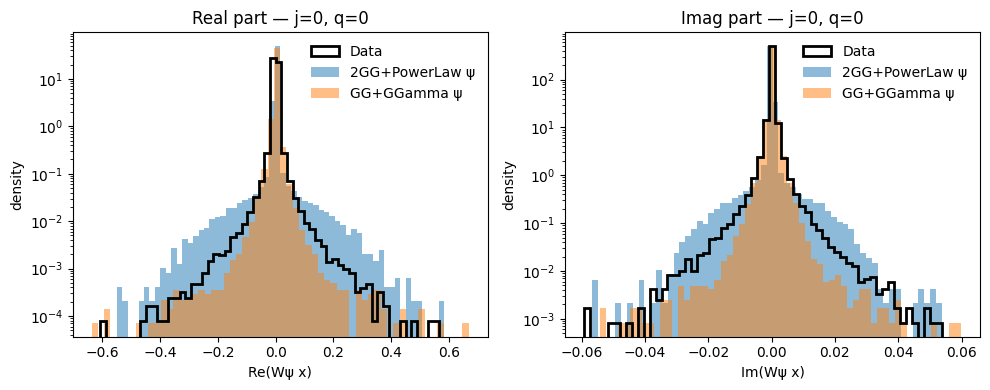

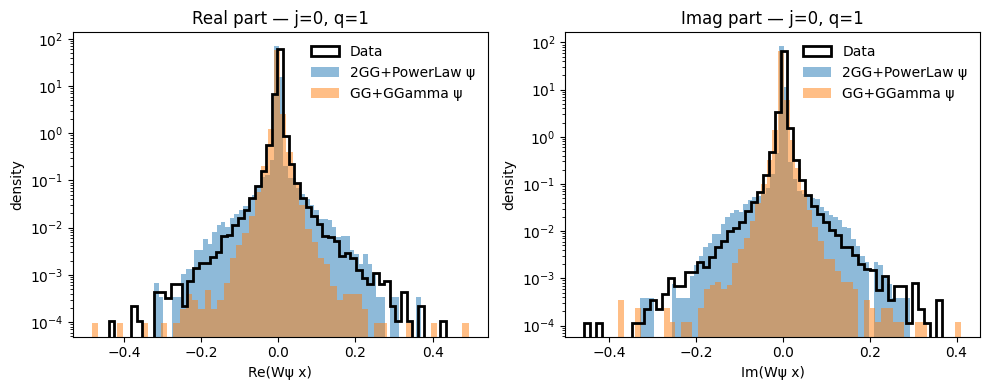

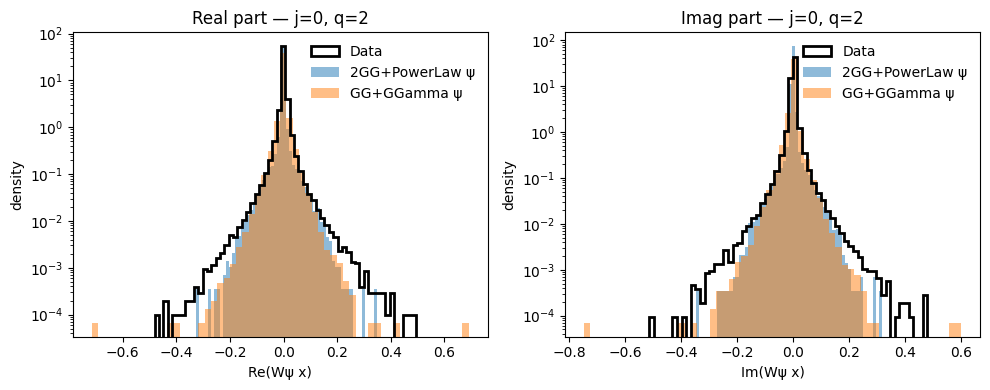

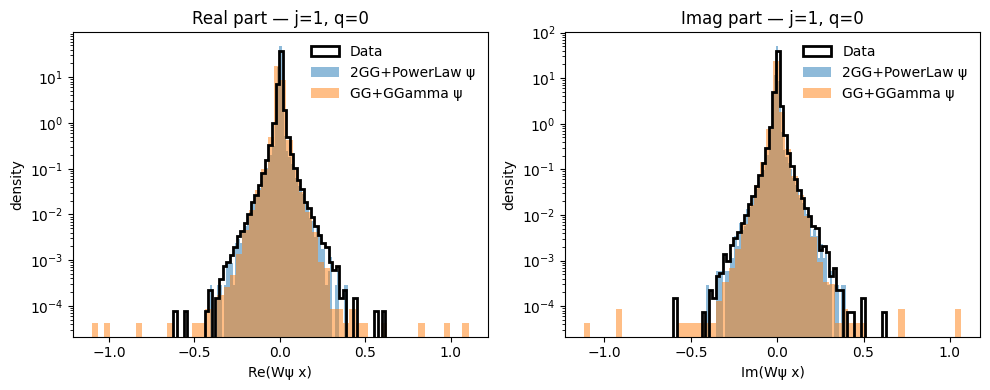

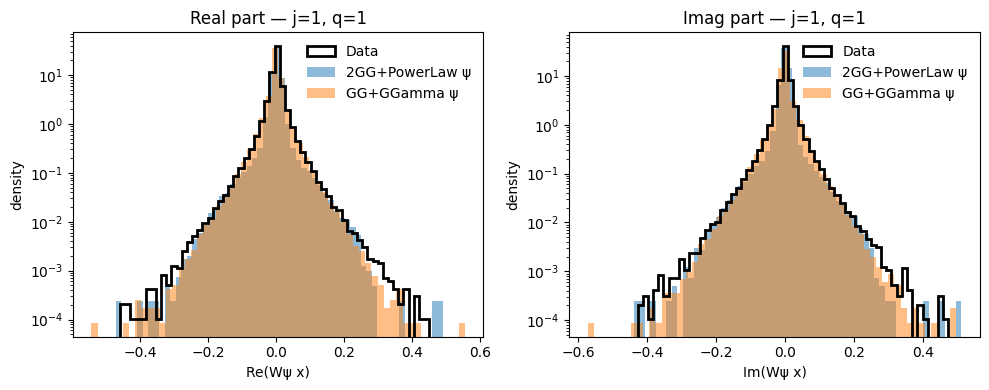

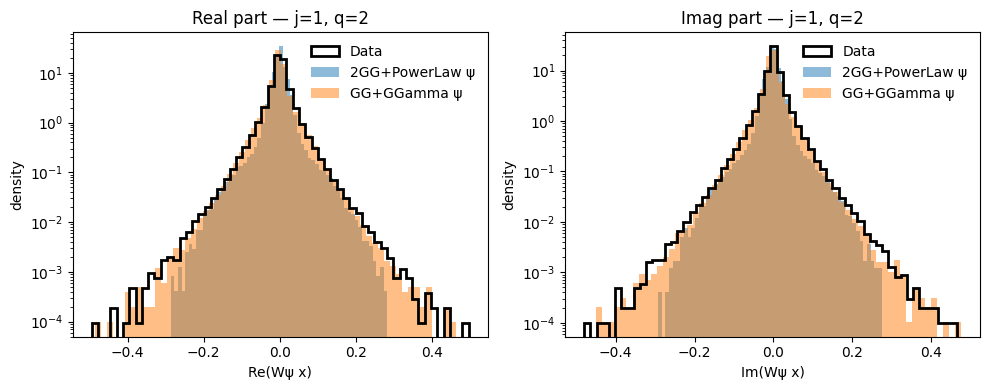

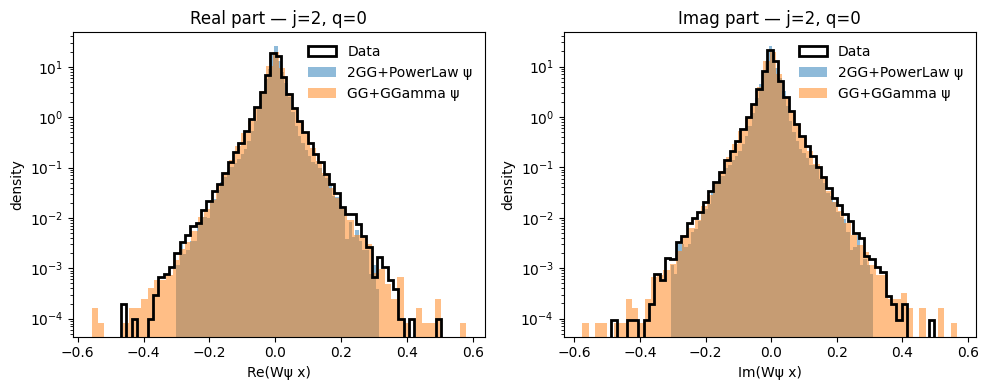

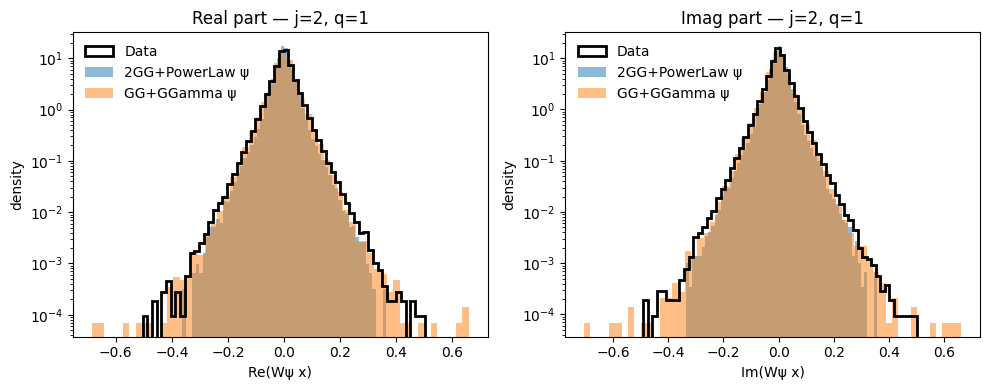

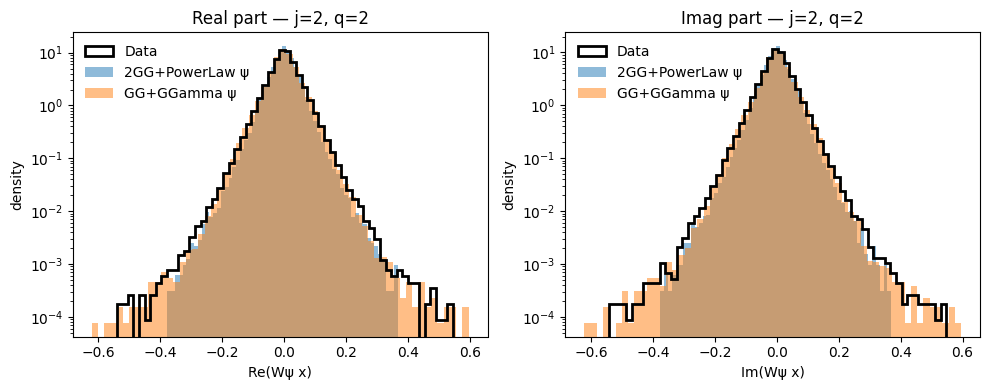

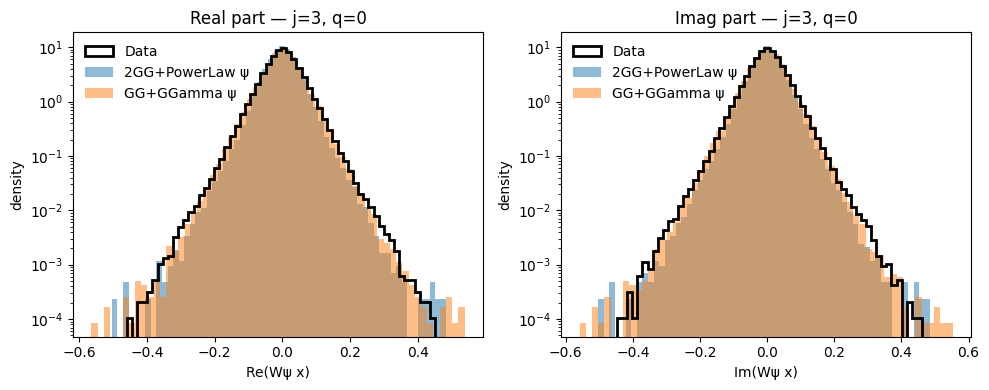

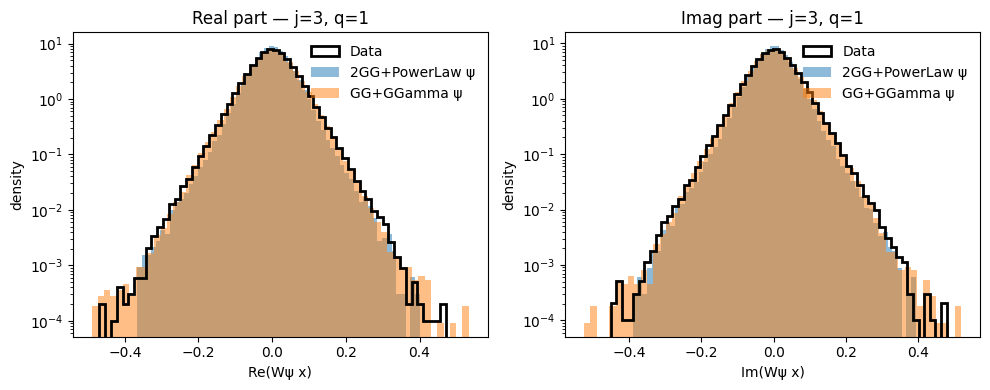

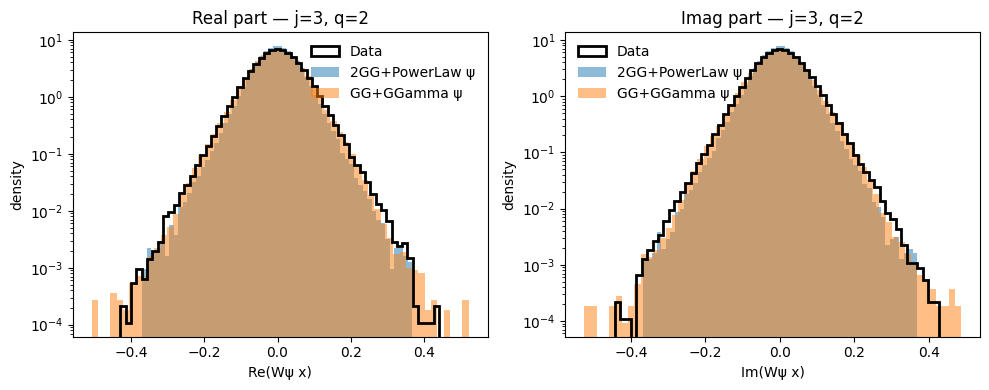

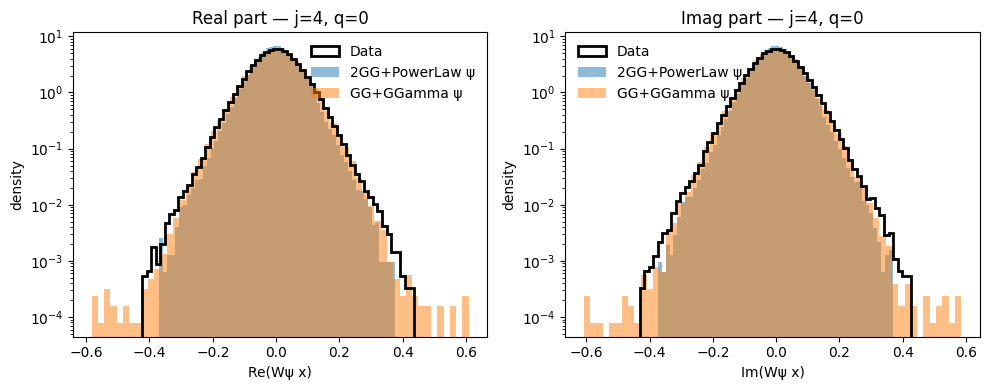

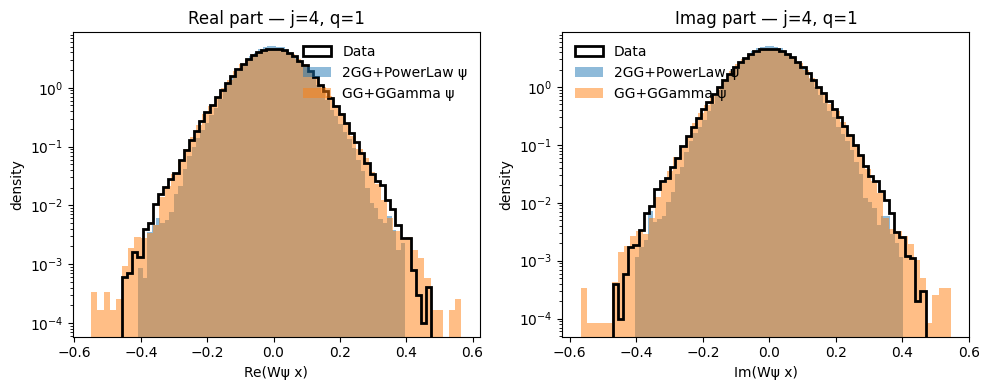

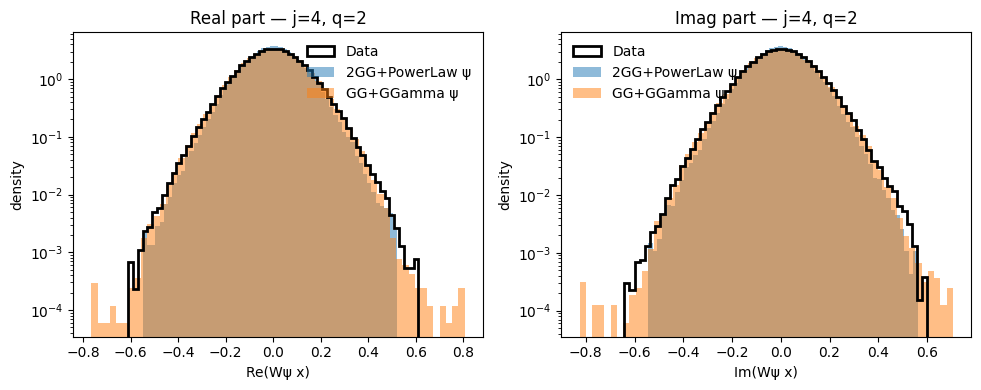

In [5]:
plot_wavelet_real_imag_histograms_overlay(x1, results, experiments) 